# Sentinel-2 Water & Urban Change Detection
---
**Location:** 20.160643°N, 102.314743°E (Laos)  
**Extent:** 10 km (5 km buffer around centre point)  
**Baseline:** Feb–Mar 2019 &nbsp;|&nbsp; **Recent:** Feb–Mar 2020  
**Sensor:** Sentinel-2 Surface Reflectance L2A (Harmonized)

### Indices Used

| Index | Formula | Role |
|-------|---------|------|
| **MNDWI** | (B3 − B11) / (B3 + B11) | Primary water detector |
| **NDBI**  | (B11 − B8) / (B11 + B8) | Primary urban detector |
| **NDVI**  | (B8 − B4) / (B8 + B4)   | Vegetation suppression filter only |

### Urban Filter Strategy
NDBI alone produces significant false positives in forested tropical terrain (shadowed canopy mimics built-up signal). Four filters are applied in combination to clean the urban mask:

1. **Slope mask** — excludes pixels on slopes > 15° using SRTM DEM. Urban development in this valley is confined to flat ground.
2. **Raised NDBI threshold** — 0.1 instead of 0.0 to reduce marginal mixed pixels.
3. **MNDWI suppression** — MNDWI < −0.1 excludes water pixels leaking into the urban mask.
4. **NDVI suppression** — NDVI < 0.2 excludes vegetated pixels (forest, crops).
5. **Minimum mapping unit (MMU)** — focal majority filter (3×3) removes isolated noise pixels.

### Change Map Classes
| Class | Label |
|-------|-------|
| 0 | Unchanged / Other (transparent) |
| 1 | Water Gained |
| 2 | Water Lost |
| 3 | Urban Gained |
| 4 | Urban Lost |
| 5 | Stable Water |
| 6 | Stable Urban |

---
### Requirements
```bash
pip install earthengine-api geemap
```
Run `ee.Authenticate()` once before first use to link your GEE account.

## 1 · Authentication & Initialisation

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


ee.Initialize(project='crucial-pagoda-493708-k4') # to run the notebook you must add your own GEE project id here

/Users/hannahnguyen/.pyenv/versions/3.10.10/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 2 · Define Area of Interest (AOI)

In [2]:
lat = 20.160643
lon = 102.314743

point    = ee.Geometry.Point([lon, lat])
aoi      = point.buffer(5000)  # 5 km radius = 10 km extent
aoi_bbox = aoi.bounds()

print(f'Centre point : {lat:.4f}N, {lon:.4f}E')
print(f'AOI          : 10 km extent (5 km buffer)')

Centre point : 20.1606N, 102.3147E
AOI          : 10 km extent (5 km buffer)


## 3 · Cloud Masking Function
Sentinel-2 L2A cloud masking uses the **QA60** bitmask band:
- **Bit 10** — Opaque clouds
- **Bit 11** — Cirrus clouds

Reflectance bands are also scaled from `[0, 10000]` to `[0, 1]`.

In [3]:
def mask_clouds_s2(image):
    """Mask clouds/cirrus and scale reflectance to [0, 1]."""
    qa60        = image.select('QA60')
    cloud_mask  = qa60.bitwiseAnd(1 << 10).eq(0)  # Bit 10: opaque cloud
    cirrus_mask = qa60.bitwiseAnd(1 << 11).eq(0)  # Bit 11: cirrus

    optical_bands = ['B1','B2','B3','B4','B5','B6','B7',
                     'B8','B8A','B9','B11','B12']
    scaled = image.select(optical_bands).divide(10000)

    return (image.addBands(scaled, overwrite=True)
                 .updateMask(cloud_mask.And(cirrus_mask))
                 .copyProperties(image, ['system:time_start']))

print('Cloud mask function defined.')

Cloud mask function defined.


## 4 · Spectral Indices

Apply three separate indices using optical bands of Sentinel-2 to distinguish changes in water and built-up surfaces. NDVI is used solely to improve urban mask detection by filtering out dark forest canopies.

- **MNDWI** — water detection using Green (B3) and SWIR1 (B11). Actively suppresses built-up and vegetation signal. Threshold > 0 reliably identifies open water.
- **NDBI** — built-up detection using SWIR1 (B11) and NIR (B8). Applied within the multi-filter approach in Section 8 rather than as a standalone threshold.
- **NDVI** — vegetation index using NIR (B8) and Red (B4). Not used for vegetation mapping — retained purely as a **suppression filter** to exclude forest canopy from the urban mask.

In [4]:
def add_indices(image):
    """Compute MNDWI (water), NDBI (urban), NDVI (suppression only)."""
    mndwi = image.normalizedDifference(['B3',  'B11']).rename('MNDWI')  # Water
    ndbi  = image.normalizedDifference(['B11', 'B8' ]).rename('NDBI')   # Urban
    ndvi  = image.normalizedDifference(['B8',  'B4' ]).rename('NDVI')   # Suppression
    return image.addBands([mndwi, ndbi, ndvi])

print('Index function defined.')

Index function defined.


## 5 · Load & Filter Sentinel-2 Collection

Using `COPERNICUS/S2_SR_HARMONIZED` — the harmonized L2A collection. Harmonization corrects for the January 2022 processing baseline change that introduced a +1000 DN offset, ensuring consistent reflectance values across all dates.

In [5]:
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(aoi)
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
                 .map(mask_clouds_s2)
                 .map(add_indices))

# Time periods
baseline_start, baseline_end = '2019-02-01', '2019-03-31'
recent_start,   recent_end   = '2020-02-01', '2020-03-31'

baseline_col = s2_collection.filterDate(baseline_start, baseline_end)
recent_col   = s2_collection.filterDate(recent_start,   recent_end)

print(f'Baseline images (Feb-Mar 2019): {baseline_col.size().getInfo()}')
print(f'Recent images   (Feb-Mar 2020): {recent_col.size().getInfo()}')

Baseline images (Feb-Mar 2019): 21
Recent images   (Feb-Mar 2020): 21


## 6 · Create Median Composites
A median composite produces a single representative image per period. The median reducer removes remaining cloud and shadow artefacts by selecting the central value across all available scenes per pixel.

In [6]:
baseline_composite = baseline_col.median().clip(aoi_bbox)
recent_composite   = recent_col.median().clip(aoi_bbox)

print('Median composites created.')
print(f'  Baseline : {baseline_start} to {baseline_end}')
print(f'  Recent   : {recent_start} to {recent_end}')

Median composites created.
  Baseline : 2019-02-01 to 2019-03-31
  Recent   : 2020-02-01 to 2020-03-31


## 7 · Slope Mask from SRTM DEM

To further improve urban detection, topography is obtained from a global Digital Elevation Model. In this steep river valley, urban development is largely confined to flat ground along the Nam Ou floodplain and valley floor. Masking pixels with slope > 15 degrees eliminates the majority of forested hillside false positives before any spectral thresholding is applied.

In [7]:
dem       = ee.Image('USGS/SRTMGL1_003')
slope     = ee.Terrain.slope(dem)
flat_mask = slope.lt(15)  # Retain pixels with slope < 15 degrees

print('Slope mask computed from SRTM DEM (30 m).')
print('Pixels with slope >= 15 degrees excluded from urban analysis.')

Slope mask computed from SRTM DEM (30 m).
Pixels with slope >= 15 degrees excluded from urban analysis.


## 8 · Water & Urban Binary Masks

### Water mask
A single MNDWI threshold is robust for open water detection:
```
MNDWI > 0  =  water
```

### Urban mask — multi-filter approach
A pixel must satisfy **all four conditions simultaneously** to be classified as urban:

| Filter | Condition | What it removes |
|--------|-----------|----------------|
| Slope  | slope < 15 degrees | Forested hillside and ridge pixels |
| NDBI   | NDBI > 0.1 | Low-signal mixed vegetation/urban pixels |
| MNDWI  | MNDWI < -0.1 | Water pixels bleeding into urban mask |
| NDVI   | NDVI < 0.2 | Vegetated pixels — forest, agriculture |

Urban areas are almost always observed as clusters of pixels rather than single pixels. A **focal majority filter** (3×3 kernel) is applied as a minimum mapping unit to remove isolated noise pixels.

In [8]:
# Tunable thresholds
water_threshold = 0.0   # MNDWI > this = water
ndbi_threshold  = 0.1   # Raised from 0.0 to reduce false positives
mndwi_urban_max = -0.1  # Exclude water signal from urban mask
ndvi_threshold  = 0.2   # Exclude vegetation from urban mask

# Water masks
water_baseline = baseline_composite.select('MNDWI').gt(water_threshold)
water_recent   = recent_composite.select('MNDWI').gt(water_threshold)

# Urban masks -- multi-filter
def make_urban_mask(composite):
    """Apply 4-layer urban filter: slope + NDBI + MNDWI suppression + NDVI suppression,
    followed by a focal majority MMU filter to remove isolated noise pixels."""
    ndbi_ok  = composite.select('NDBI').gt(ndbi_threshold)
    water_ok = composite.select('MNDWI').lt(mndwi_urban_max)  # not water
    veg_ok   = composite.select('NDVI').lt(ndvi_threshold)    # not vegetation
    spectral = ndbi_ok.And(water_ok).And(veg_ok)
    urban    = spectral.updateMask(flat_mask)
    return urban.focal_mode(radius=1, kernelType='square', iterations=1)

urban_baseline = make_urban_mask(baseline_composite)
urban_recent   = make_urban_mask(recent_composite)

print('Water and urban masks computed.')
print(f'  Water  : MNDWI > {water_threshold}')
print(f'  Urban  : NDBI > {ndbi_threshold}, MNDWI < {mndwi_urban_max}, NDVI < {ndvi_threshold}, slope < 15 deg')
print(f'  MMU    : 3x3 focal majority filter applied')

Water and urban masks computed.
  Water  : MNDWI > 0.0
  Urban  : NDBI > 0.1, MNDWI < -0.1, NDVI < 0.2, slope < 15 deg
  MMU    : 3x3 focal majority filter applied


## 9 · Continuous Change Differencing
Subtract baseline index values from recent values for MNDWI and NDBI. These continuous layers complement the binary change map and show the *magnitude* of change, useful for identifying areas of subtle transition.

In [9]:
mndwi_change = (recent_composite.select('MNDWI')
                .subtract(baseline_composite.select('MNDWI'))
                .rename('MNDWI_change'))

ndbi_change  = (recent_composite.select('NDBI')
                .subtract(baseline_composite.select('NDBI'))
                .rename('NDBI_change'))

print('Continuous change layers computed.')
print('  Positive MNDWI change = more water in recent period')
print('  Positive NDBI change  = more built-up in recent period')

Continuous change layers computed.
  Positive MNDWI change = more water in recent period
  Positive NDBI change  = more built-up in recent period


## 10 · Multi-Class Change Map

Combine the binary masks into a 7-class change map by comparing each pixel's state in the baseline vs recent period. Stable classes are painted first, then losses, then gains — so gains take visual priority in any overlap.

| Value | Class | Colour |
|-------|-------|--------|
| 0 | Unchanged / Other | Transparent |
| 1 | Water Gained | Blue |
| 2 | Water Lost | Fuchsia |
| 3 | Urban Gained | Red |
| 4 | Urban Lost | Yellow |
| 5 | Stable Water | Light blue |
| 6 | Stable Urban | Deep maroon |

In [10]:
water_gained = water_recent.And(water_baseline.Not())
water_lost   = water_baseline.And(water_recent.Not())
urban_gained = urban_recent.And(urban_baseline.Not()).And(water_recent.Not())
urban_lost   = urban_baseline.And(urban_recent.Not()).And(water_baseline.Not())
stable_water = water_baseline.And(water_recent)
stable_urban = urban_baseline.And(urban_recent).And(water_baseline.Not())

change_map = (ee.Image(0)
              .where(stable_water,  5)
              .where(stable_urban,  6)
              .where(water_lost,    2)
              .where(urban_lost,    4)
              .where(water_gained,  1)
              .where(urban_gained,  3)
              .rename('change_map')
              .clip(aoi_bbox))

print('Change map computed.')

Change map computed.


## 11 · Time Series at Point
Extract MNDWI and NDBI values at the centre point for every available scene across the full 2015–2020 period. This reveals the temporal trajectory of change rather than just a snapshot comparison.

In [11]:
full_collection = s2_collection.filterDate('2015-07-01', '2020-12-31')

print(f'Total scenes in full period: {full_collection.size().getInfo()}')

Total scenes in full period: 133


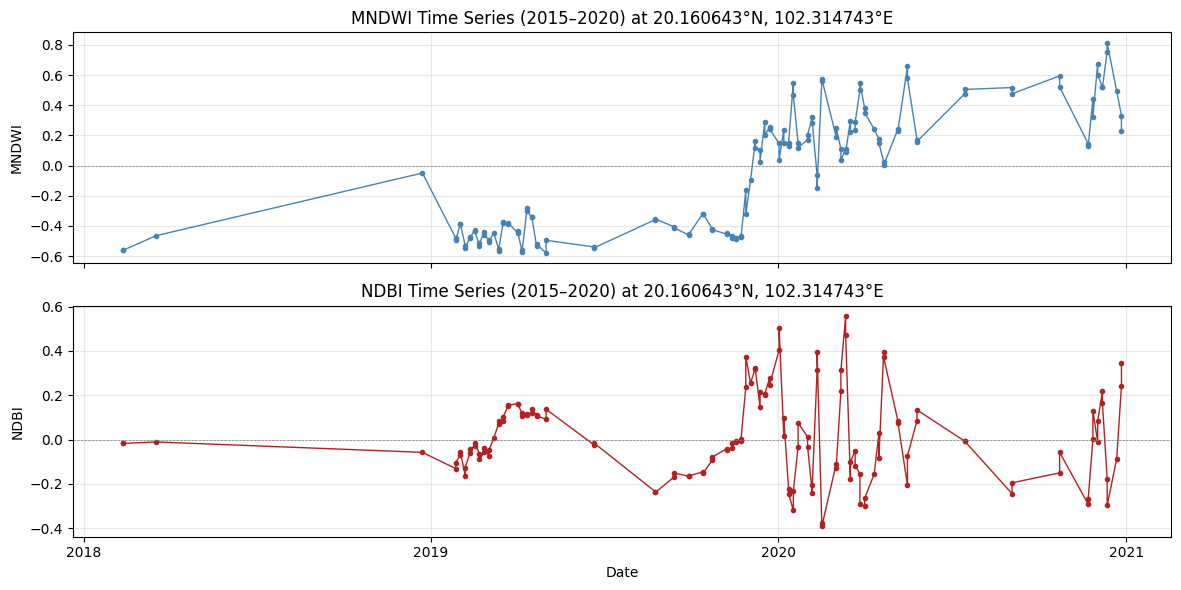

In [12]:
def extract_indices(image):
    val = image.reduceRegion(ee.Reducer.mean(), point, 10)
    return ee.Feature(None, {
        'MNDWI': val.get('MNDWI'),
        'NDBI':  val.get('NDBI'),
        'date':  image.date().format('YYYY-MM-dd')
    })

ts_df = geemap.ee_to_df(ee.FeatureCollection(full_collection.map(extract_indices))).dropna()
ts_df['date'] = pd.to_datetime(ts_df['date'])
ts_df = ts_df.sort_values('date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(ts_df['date'], ts_df['MNDWI'], marker='o', markersize=3, linewidth=1, color='steelblue')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_title(f'MNDWI Time Series (2015–2020) at {lat}°N, {lon}°E')
ax1.set_ylabel('MNDWI')
ax1.grid(True, alpha=0.3)

ax2.plot(ts_df['date'], ts_df['NDBI'], marker='o', markersize=3, linewidth=1, color='firebrick')
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax2.set_title(f'NDBI Time Series (2015–2020) at {lat}°N, {lon}°E')
ax2.set_ylabel('NDBI')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

## 12 · Interactive Map

All layers are added below. Toggle visibility using the layer panel in the top-right of the map.

**Recommended inspection order:**
1. **True Colour** — orient to the landscape
2. **Water / Urban Masks** — verify filter quality against known features
3. **MNDWI / NDBI Change** — examine magnitude of change continuously
4. **Water & Urban Change Map** — primary analytical output

In [13]:
Map = geemap.Map()
Map.add_basemap('Stadia.AlidadeSmoothDark')
Map.centerObject(point, zoom=12)

# Visualisation parameters
vis_true_color  = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}
vis_change_cont = {'min': -0.3, 'max': 0.3, 'palette': ['d73027', 'ffffbf', '1a9850']}
vis_change_map  = {'min': 0, 'max': 6,
                   'palette': ['000000',   # 0 Unchanged (masked out via selfMask)
                               '2196F3',   # 1 Water Gained  — vivid blue
                               'FF00AA',   # 2 Water Lost    — fuchsia/pink
                               'F44336',   # 3 Urban Gained  — red
                               'FFE000',   # 4 Urban Lost    — yellow
                               '03A9F4',   # 5 Stable Water  — light blue
                               '880E4F']}  # 6 Stable Urban  — deep maroon

# Composite layers
Map.addLayer(baseline_composite, vis_true_color, 'Baseline True Colour (Feb-Mar 2019)', shown=False)
Map.addLayer(recent_composite,   vis_true_color, 'Recent True Colour (Feb-Mar 2020)',   shown=False)

# Primary output — selfMask() makes class 0 (Unchanged) transparent
Map.addLayer(change_map.selfMask(), vis_change_map, 'Water and Urban Change Map')
Map.addLayer(point, {'color': 'cyan'}, 'Centre Point')

# Binary mask verification layers
Map.addLayer(water_baseline.selfMask(), {'palette': ['2196F3']}, 'Water Mask — Baseline', shown=False)
Map.addLayer(water_recent.selfMask(),   {'palette': ['2196F3']}, 'Water Mask — Recent',   shown=False)
Map.addLayer(urban_baseline.selfMask(), {'palette': ['F44336']}, 'Urban Mask — Baseline', shown=False)
Map.addLayer(urban_recent.selfMask(),   {'palette': ['F44336']}, 'Urban Mask — Recent',   shown=False)

# Legend
legend_keys   = ['Water Gained', 'Water Lost', 'Urban Gained', 'Urban Lost',
                 'Stable Water', 'Stable Urban']
legend_colors = ['#2196F3', '#FF00AA', '#F44336', '#FFE000', '#03A9F4', '#880E4F']
Map.add_legend(title='Water & Urban Change', keys=legend_keys, colors=legend_colors)

Map

Map(center=[20.160642999999997, 102.314743], controls=(WidgetControl(options=['position', 'transparent_bg'], p…

## 13 · Area Change Statistics

In [14]:
area_image = ee.Image.pixelArea().addBands(change_map)

area_stats = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=aoi_bbox,
    scale=10,
    maxPixels=1e10
)

class_labels = {
    0: 'Unchanged / Other',
    1: 'Water Gained',
    2: 'Water Lost',
    3: 'Urban Gained',
    4: 'Urban Lost',
    5: 'Stable Water',
    6: 'Stable Urban',
}

groups   = {g['class']: g['sum'] / 10000 for g in area_stats.getInfo()['groups']}
total_ha = sum(groups.values())

print(f"{'Class':<22} {'Area (ha)':>10}  {'% AOI':>7}")
print('─' * 43)
for cls, label in class_labels.items():
    ha  = groups.get(cls, 0)
    pct = (ha / total_ha) * 100
    print(f'  {label:<20} {ha:>10,.1f}  {pct:>6.1f}%')
print('─' * 43)
print(f"  {'Total AOI':<20} {total_ha:>10,.1f}  {'100.0%':>7}")

water_gained_ha = groups.get(1, 0)
water_lost_ha   = groups.get(2, 0)
urban_gained_ha = groups.get(3, 0)
urban_lost_ha   = groups.get(4, 0)

Class                   Area (ha)    % AOI
───────────────────────────────────────────
  Unchanged / Other       9,408.8    94.9%
  Water Gained              140.5     1.4%
  Water Lost                 10.3     0.1%
  Urban Gained              167.3     1.7%
  Urban Lost                  4.0     0.0%
  Stable Water              150.7     1.5%
  Stable Urban               33.9     0.3%
───────────────────────────────────────────
  Total AOI               9,915.6   100.0%

  Net water change : +130.2 ha
  Net urban change : +163.3 ha


## 14 · Export Change Map as COG

Downloads the change map at 10 m resolution and writes it as a **Cloud Optimized GeoTIFF** (COG) using GDAL's COG driver.
The raw download is removed after conversion.

**Requirements:** GDAL ≥ 3.1 (`gdal_translate` on PATH). Install via `conda install -c conda-forge gdal` or `brew install gdal`.

In [15]:
import subprocess
from pathlib import Path

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)

raw_tif = output_dir / 'laos_change_map_raw.tif'
cog_tif = output_dir / 'laos_change_map_cog.tif'

# Download from GEE at native 10 m resolution
geemap.ee_export_image(
    change_map.unmask(0).byte(),
    filename=str(raw_tif),
    scale=10,
    region=aoi_bbox,
    crs='EPSG:4326',
    file_per_band=False,
)

# Convert to COG with DEFLATE compression and nearest-neighbour resampling
subprocess.run(
    [
        'gdal_translate', str(raw_tif), str(cog_tif),
        '-of', 'COG',
        '-co', 'COMPRESS=DEFLATE',
        '-co', 'PREDICTOR=2',
        '-co', 'RESAMPLING=NEAREST',
    ],
    check=True,
)

raw_tif.unlink()  # remove intermediate file
print(f'COG written to: {cog_tif.resolve()}')
print(f'File size     : {cog_tif.stat().st_size / 1024:.1f} KB')

Generating URL ...
Please wait ...
Data downloaded to /Users/hannahnguyen/Documents/work_folders/amnesty_demo/laos_dam_change_detection/outputs/laos_change_map_raw.tif
COG written to: /Users/hannahnguyen/Documents/work_folders/amnesty_demo/laos_dam_change_detection/outputs/laos_change_map_cog.tif
File size     : 32.1 KB
